In [4]:
!pip install earthengine-api geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.7 MB/s eta 0:00:00


In [5]:
!pip install geemap

import ee
import geemap

ee.Authenticate()
ee.Initialize(project='ee-napaporn3401')

In [6]:
thailand = ee.FeatureCollection('FAO/GAUL/2015/level1') \
    .filter(ee.Filter.eq('ADM0_NAME', 'Thailand'))

suphan = thailand.filter(
    ee.Filter.eq('ADM1_NAME', 'Suphanburi')
)

aoi = suphan.geometry()

print('✅ AOI: Suphanburi')
print("Size:", suphan.size().getInfo())

✅ AOI: Suphanburi
Size: 1


In [10]:
import geemap

Map = geemap.Map()

In [11]:
Map.centerObject(aoi, 9)

Map.addLayer(
    aoi,
    {'color': 'red'},
    'Suphanburi Boundary'
)

Map

Map(center=[14.609451848374158, 99.89534099645113], controls=(WidgetControl(options=['position', 'transparent_…

In [12]:
def maskL8sr(image):
    # cloud mask
    qa = image.select('QA_PIXEL')
    cloud = qa.bitwiseAnd(int('11111', 2)).eq(0)

    # saturation mask
    sat = image.select('QA_RADSAT').eq(0)

    # scale reflectance
    optical = image.select(['SR_B2','SR_B3','SR_B4','SR_B5','SR_B6']) \
                   .multiply(0.0000275).add(-0.2)

    return optical.updateMask(cloud).updateMask(sat)

In [13]:
l8 = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
      .filterBounds(aoi)
      .filterDate('2022-01-01', '2023-12-31')

      # เลือกฤดูแล้ง (เมฆน้อย)
      .filter(ee.Filter.calendarRange(11, 4, 'month'))

      .map(maskL8sr)
)

In [14]:
image = l8.median().clip(aoi)

In [15]:
print("Number of images:", l8.size().getInfo())
print("Bands:", image.bandNames().getInfo())

Number of images: 63
Bands: ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6']


In [16]:
Map.addLayer(
    image,
    {
        'bands':['SR_B4','SR_B3','SR_B2'],
        'min': 0,
        'max': 0.25,
        'gamma': 1.3
    },
    'Final RGB'
)
Map

Map(bottom=60458.0, center=[14.609451848374158, 99.89534099645113], controls=(WidgetControl(options=['position…

In [17]:
# NDVI (พืช)
ndvi = image.normalizedDifference(['SR_B5','SR_B4']).rename('NDVI')

# NDWI (น้ำ)
ndwi = image.normalizedDifference(['SR_B3','SR_B5']).rename('NDWI')

# NDBI (เมือง)
ndbi = image.normalizedDifference(['SR_B6','SR_B5']).rename('NDBI')

# รวมเข้า image
image = image.addBands([ndvi, ndwi, ndbi])

# band ที่ใช้ train
bands = ['SR_B2','SR_B3','SR_B4','SR_B5','SR_B6','NDVI','NDWI','NDBI']

In [18]:
dw = (ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
      .filterBounds(aoi)
      .filterDate('2022-01-01', '2023-12-31')
      .select('label')
      .mode()
      .clip(aoi))

Map.addLayer(dw, {}, 'Dynamic World')
Map

Map(bottom=60458.0, center=[14.609451848374158, 99.89534099645113], controls=(WidgetControl(options=['position…

In [19]:
def reclass(img):
    return img.remap(
        [0,1,2,3,4,5,6,7],
        [0,1,2,0,2,1,3,4]
    ).rename('landcover')

dw_reclass = reclass(dw)

Map.addLayer(dw_reclass, {}, 'Reclass')
Map

Map(bottom=60458.0, center=[14.609451848374158, 99.89534099645113], controls=(WidgetControl(options=['position…

In [20]:
training = image.addBands(dw_reclass).sample(
    region=aoi,
    scale=30,
    numPixels=3000,
    seed=42
)

print("Training size:", training.size().getInfo())

Training size: 3000


In [21]:
withRandom = training.randomColumn('random')

train = withRandom.filter('random < 0.8')
test = withRandom.filter('random >= 0.8')

In [22]:
rf = ee.Classifier.smileRandomForest(100).train(
    features=train,
    classProperty='landcover',
    inputProperties=bands
)

rf_classified = image.select(bands).classify(rf)

In [23]:
svm = ee.Classifier.libsvm(
    kernelType='RBF',
    gamma=0.5,
    cost=10
).train(
    train, 'landcover', bands
)

svm_classified = image.select(bands).classify(svm)

In [24]:
# RF
rf_test = test.classify(rf)
rf_cm = rf_test.errorMatrix('landcover', 'classification')

print("RF Accuracy:", rf_cm.accuracy().getInfo())
print("RF Confusion Matrix:", rf_cm.getInfo())

# SVM
svm_test = test.classify(svm)
svm_cm = svm_test.errorMatrix('landcover', 'classification')

print("SVM Accuracy:", svm_cm.accuracy().getInfo())

RF Accuracy: 0.7633228840125392
RF Confusion Matrix: [[51, 0, 21, 2, 0], [0, 85, 27, 2, 0], [24, 10, 322, 9, 0], [1, 10, 43, 29, 0], [0, 0, 1, 1, 0]]
SVM Accuracy: 0.7351097178683386


In [26]:
palette = [
    '0000FF',  # water
    '008000',  # forest
    'FFFF00',  # agriculture
    'FF0000',  # urban
    'A52A2A'   # bare
]

Map.centerObject(aoi, 9)

Map.addLayer(rf_classified, {'min':0,'max':4,'palette':palette}, 'RF LULC')
Map.addLayer(svm_classified, {'min':0,'max':4,'palette':palette}, 'SVM LULC')

legend_dict = {
    'Water': '0000FF',
    'Forest': '008000',
    'Agriculture': 'FFFF00',
    'Urban': 'FF0000',
    'Bare land': 'A52A2A'
}

Map.add_legend(
    title='Land Use / Land Cover',
    legend_dict=legend_dict
)

Map

Map(bottom=60458.0, center=[14.609451848374158, 99.89534099645113], controls=(WidgetControl(options=['position…

In [27]:
importance = rf.explain().get('importance')
print(ee.Dictionary(importance).getInfo())

{'NDBI': 763.296198492732, 'NDVI': 722.5368451911532, 'NDWI': 764.8482552334781, 'SR_B2': 803.1196804313819, 'SR_B3': 758.1924582480883, 'SR_B4': 774.1118825226592, 'SR_B5': 724.6482921079202, 'SR_B6': 819.0052300869081}


In [34]:
import geemap
import ee

Map = geemap.Map()
Map.centerObject(aoi, 9)

palette = [
    '1f78b4',  # water
    '33a02c',  # forest
    'ffcc33',  # agriculture
    'e31a1c',  # urban
    'b15928'   # bare
]

Map.addLayer(rf_classified, {'min':0,'max':4,'palette':palette}, 'LULC (RF)')

legend_dict = {
    'Water': '1f78b4',
    'Forest': '33a02c',
    'Agriculture': 'ffcc33',
    'Urban': 'e31a1c',
    'Bare land': 'b15928'
}

Map.add_legend(
    title='Land Use / Land Cover',
    legend_dict=legend_dict
)

Map

Map(center=[14.609451848374158, 99.89534099645113], controls=(WidgetControl(options=['position', 'transparent_…

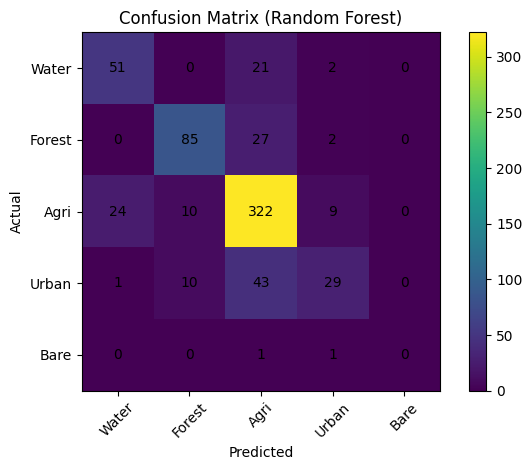

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# ดึงค่า RF confusion matrix
cm = np.array(rf_cm.getInfo())

classes = ['Water','Forest','Agri','Urban','Bare']

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (Random Forest)")
plt.colorbar()

plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

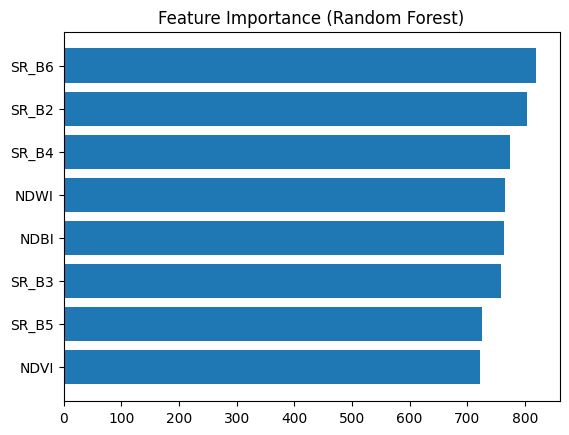

In [36]:
import pandas as pd

importance_dict = ee.Dictionary(importance).getInfo()

df = pd.DataFrame({
    'Feature': list(importance_dict.keys()),
    'Importance': list(importance_dict.values())
}).sort_values(by='Importance', ascending=False)

plt.figure()
plt.barh(df['Feature'], df['Importance'])
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

In [32]:
rf_50 = ee.Classifier.smileRandomForest(50).train(train, 'landcover', bands)
rf_100 = ee.Classifier.smileRandomForest(100).train(train, 'landcover', bands)
rf_200 = ee.Classifier.smileRandomForest(200).train(train, 'landcover', bands)

In [33]:
print("Kappa:", rf_cm.kappa().getInfo())
print("Producers:", rf_cm.producersAccuracy().getInfo())
print("Users:", rf_cm.consumersAccuracy().getInfo())

Kappa: 0.5896511920126423
Producers: [[0.6891891891891891], [0.7456140350877193], [0.8821917808219178], [0.3493975903614458], [0]]
Users: [[0.6710526315789473, 0.8095238095238095, 0.7777777777777778, 0.6744186046511628, 0]]
